# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt# importar librerías

In [3]:

plans = pd.read_csv('/datasets/plans.csv')

users = pd.read_csv('/datasets/users_latam.csv')

usage = pd.read_csv('/datasets/usage.csv')

In [4]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [14]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [16]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---
*
*Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

city: 469 valores faltantes (11,73 %). Se recomienda investigar y mantener como nulos si no podemos determinar la ciudad correctamente.
churn_date: 3.534 valores faltantes (88,35 %). Se recomienda mantener como nulos, ya que probablemente indican que el usuario no ha abandonado el servicio.
date: 50 valores faltantes (0,125 %). Por ser una proporción muy pequeña, se pueden ignorar o mantener como nulos.
duration: 22.076 valores faltantes (55,19 %). Se recomienda investigar antes de imputar, comprobando si dependen del tipo de registro.
length: 17.896 valores faltantes (44,74 %). Se recomienda investigar antes de imputar, comprobando si dependen del tipo de registro.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [17]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


La columna user_id presenta valores entre 10.000 y 13.999, sin valores aparentemente inválidos.
La columna age presenta un valor mínimo de -999, que es imposible para una edad e identifica un sentinel. El valor máximo de 79 es razonable. Más adelante reemplazaremos el sentinel por la mediana.

In [18]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



- La columna `id` presenta valores entre 1 y 40.000, sin valores aparentemente inválidos.
- La columna `user_id` presenta valores entre 10.000 y 13.999, coincidiendo con el rango observado en el dataset de usuarios.
- La columna `duration` presenta valores entre 0 y 120 minutos, sin valores negativos ni aparentemente imposibles.
- La columna `length` presenta valores entre 0 y 1.490. El máximo es considerablemente superior al 75% de los datos, por lo que podría haber valores extremos (outliers). Se analizarán posteriormente antes de decidir si deben conservarse o eliminarse.

In [19]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nValores únicos de {col}:")
    print(users[col].unique())



Valores únicos de city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Valores únicos de plan:
['Basico' 'Premium']



### Variables categóricas

- La columna `city` contiene seis ciudades válidas: Medellín, CDMX, Bogotá, GDL, MTY y Cali. También presenta valores `NaN` y el valor `'?'`, que se considera un sentinel y deberá tratarse como valor ausente.
- La columna `plan` contiene únicamente dos categorías: `Basico` y `Premium`, ambas válidas.

In [20]:
# explorar columna categórica de usage
print(usage['type'].unique())# completa el código

['call' 'text']


### Variable categórica `type`

- La columna `type` contiene únicamente dos categorías: `call` y `text`.
- Ambas categorías son válidas y no se observan valores inesperados o sentinels.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- ### Diagnóstico de valores inválidos y sentinels

- Se identifica el valor `-999` en `age` como un sentinel que debe sustituirse posteriormente por un valor válido.
- Se identifica el valor `'?'` en `city` como un sentinel que debe tratarse como valor ausente.
- No se observan valores inválidos evidentes en `user_id`, `id`, `duration`, `plan` ni `type`.
- La variable `length` presenta valores extremos que deberán analizarse posteriormente para determinar si son outliers y decidir si deben conservarse. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [21]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [22]:
# Convertir a fecha la columna `date` de usage
print(users['reg_date'].dt.year.value_counts().sort_index())
print(usage['date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64
2024.0    39950
Name: date, dtype: int64


In [24]:
# En `reg_date`, la mayoría de los registros corresponden a los años 2022, 2023 y 2024. Sin embargo, aparecen 40 registros con fecha de 2026, que está fuera del periodo de análisis.Revisar los años presentes en `reg_date` de users


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
En `reg_date`, la mayoría de los registros corresponden a los años 2022, 2023 y 2024. Sin embargo, aparecen 40 registros con fecha de 2026, que está fuera del periodo de análisis.

In [ ]:
# Revisar los años presentes en `date` de usage


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.
En `date`, todos los registros con fecha válida corresponden al año 2024. Además, existen 50 valores faltantes que fueron convertidos a `NaT`.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- ### Fechas fuera de rango

- En `reg_date` se detectan 40 registros correspondientes al año 2026. Estas fechas son inválidas porque los datos del proyecto llegan hasta 2024.
- En `usage['date']` no se detectan años fuera de rango; todos los registros con fecha válida corresponden a 2024.
- Se recomienda convertir las fechas de `reg_date` correspondientes a 2026 en valores ausentes (`NaT`), ya que no podemos considerar como válida una fecha futura respecto al periodo de los datos.
- Los valores faltantes de `usage['date']` se mantendrán como `NaT` y se tratarán posteriormente según su impacto en el análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [25]:

# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [26]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].unique())

['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


In [27]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts().sort_index())


2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [28]:
# Verificación MAR en usage (Missing At Random) para duration
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))


type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [29]:
# Verificación MAR en usage (Missing At Random) para length
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))


type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
### Diagnóstico de valores nulos en `duration` y `length`

- Los valores nulos de `duration` dependen del tipo de registro: en `call` no hay valores nulos, mientras que en `text` el 99,93% son nulos.
- Los valores nulos de `length` también dependen del tipo de registro: en `call` el 99,93% son nulos, mientras que en `text` no hay valores nulos.
- Por tanto, se confirma que estos valores son MAR respecto a la variable `type`.
- Se mantienen los valores nulos sin imputarlos, ya que no representan datos faltantes que debamos estimar, sino que indican que la variable no es aplicable a ese tipo de registro.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [30]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    total_calls=("is_call", "sum"),
    total_texts=("is_text", "sum"),
    total_minutes=("duration", "sum"),
    total_mb=("length", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,total_calls,total_texts,total_minutes,total_mb
0,10000,3,7,23.70,258.0
1,10001,10,5,33.18,226.0
2,10002,2,5,10.74,225.0


In [31]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "total_calls": "total_llamadas",
    "total_texts": "total_mensajes",
    "total_minutes": "total_minutos",
    "total_mb": "total_mb"
})

# observar resultado
usage_agg.head(3)

,user_id,total_llamadas,total_mensajes,total_minutos,total_mb
0,10000,3,7,23.70,258.0
1,10001,10,5,33.18,226.0
2,10002,2,5,10.74,225.0


In [32]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_llamadas,total_mensajes,total_minutos,total_mb
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,258.0
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,226.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,225.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,530.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,229.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [36]:
# Resumen estadístico de las columnas numéricas
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'total_llamadas', 'total_mensajes', 'total_minutos', 'total_mb']].describe()


,age,total_llamadas,total_mensajes,total_minutos,total_mb
count,4000.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,4.478120,5.524381,23.317054,288.128032
std,17.689919,2.144238,2.358416,18.168095,180.906841
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,3.000000,4.000000,11.120000,184.000000
50%,48.000000,4.000000,5.000000,19.780000,268.000000
75%,63.000000,6.000000,7.000000,31.415000,361.000000
max,79.000000,15.000000,17.000000,155.690000,2028.000000


In [37]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

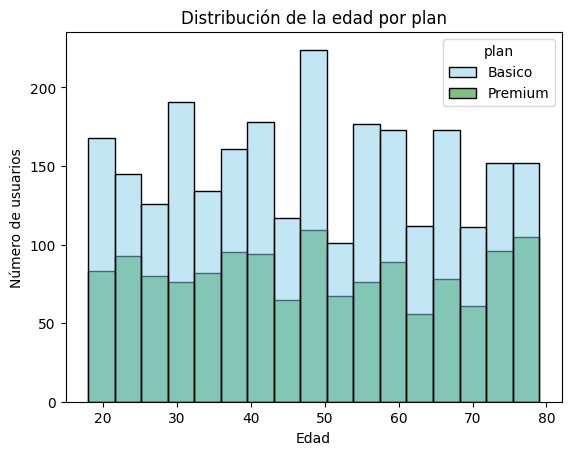

In [38]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de la edad por plan')
plt.xlabel('Edad')
plt.ylabel('Número de usuarios')
plt.show()


**Insight:** La distribución de edades es bastante similar entre los usuarios de los planes Básico y Premium. Los usuarios se encuentran entre aproximadamente 18 y 79 años y no se observa una diferencia clara en la edad según el tipo de plan. La distribución es relativamente uniforme, sin un sesgo marcado hacia la derecha o hacia la izquierda.

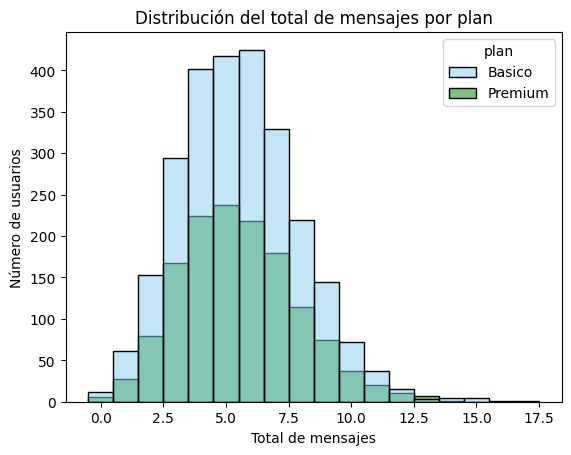

In [39]:
# Histograma para visualizar el total de mensajes
sns.histplot(
    data=user_profile,
    x='total_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    discrete=True
)
plt.title('Distribución del total de mensajes por plan')
plt.xlabel('Total de mensajes')
plt.ylabel('Número de usuarios')
plt.show()



💡Insights: 
Los usuarios del plan Básico tienden a enviar menos mensajes que los usuarios del plan Premium. La distribución se concentra principalmente entre 3 y 7 mensajes, aunque existen algunos usuarios con un número mayor de mensajes. La distribución presenta un ligero sesgo hacia la derecha, debido a los usuarios que envían una cantidad de mensajes superior a la habitual.

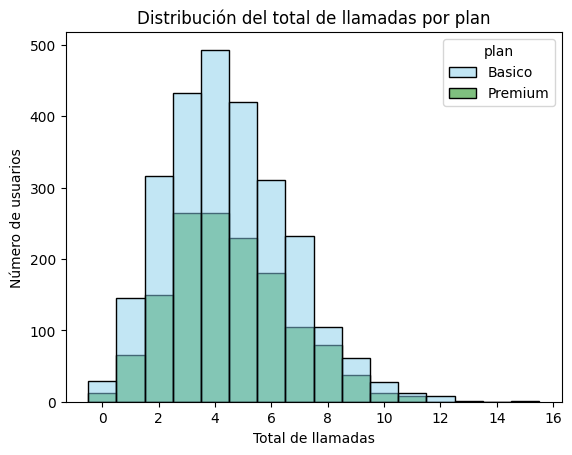

In [40]:
# Histograma para visualizar la cant_llamadas
# Histograma para visualizar el total de llamadas

sns.histplot(
    data=user_profile,
    x='total_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    discrete=True
)

plt.title('Distribución del total de llamadas por plan')
plt.xlabel('Total de llamadas')
plt.ylabel('Número de usuarios')
plt.show()


💡Insights: 
La cantidad de llamadas se concentra principalmente entre 3 y 6 llamadas por usuario. Los usuarios del plan Básico presentan una distribución similar a los usuarios Premium, aunque el plan Premium muestra algunos usuarios con una mayor cantidad de llamadas. La distribución presenta un sesgo hacia la derecha, debido a algunos usuarios con un número de llamadas superior al habitual.

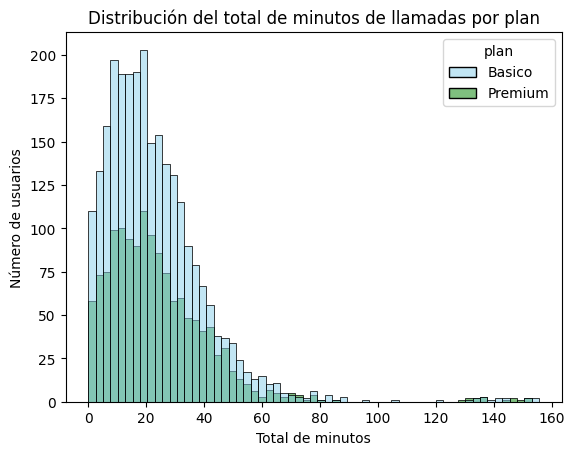

In [41]:
# Histograma para visualizar la cant_minutos_llamada
# Histograma para visualizar el total de minutos de llamadas

sns.histplot(
    data=user_profile,
    x='total_minutos',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución del total de minutos de llamadas por plan')
plt.xlabel('Total de minutos')
plt.ylabel('Número de usuarios')
plt.show()


💡Insights: 
La mayoría de los usuarios acumula un número relativamente bajo de minutos de llamadas, concentrándose principalmente entre aproximadamente 10 y 30 minutos. Los usuarios Premium presentan algunos valores de consumo superiores. La distribución está sesgada hacia la derecha, ya que existen usuarios con un número de minutos considerablemente mayor que la mayoría.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

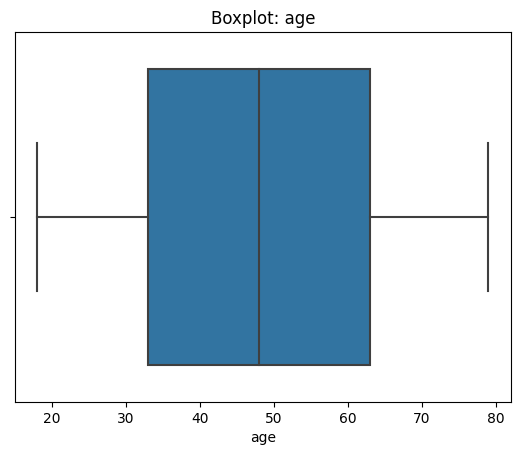

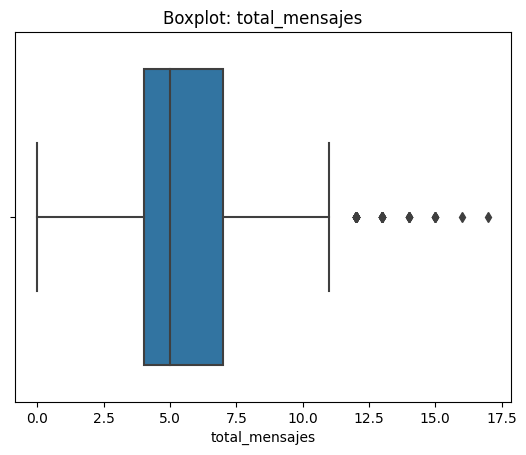

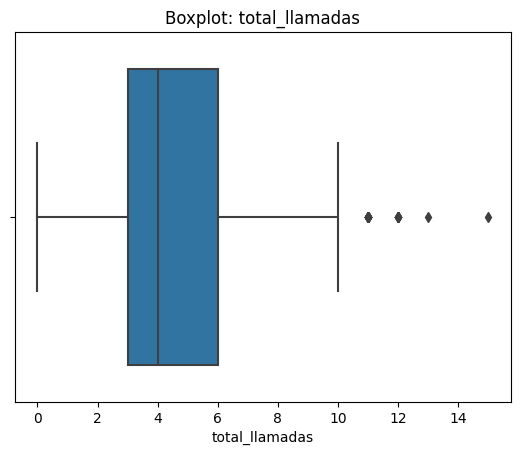

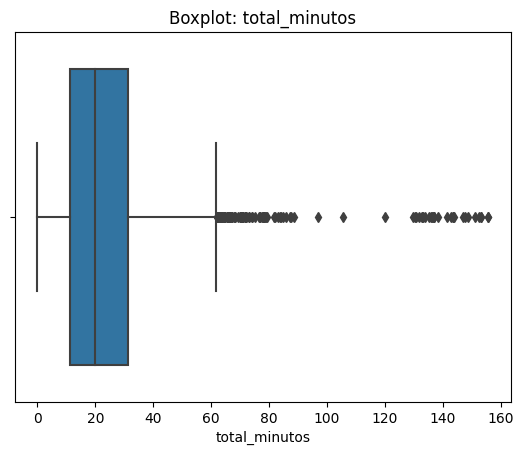

In [42]:
# Visualizando usando BoxPlot 

columnas_numericas = [
    'age',
    'total_mensajes',
    'total_llamadas',
    'total_minutos'
]

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: No presenta outliers relevantes. Los valores se encuentran entre 18 y 79 años y, después de sustituir el sentinel -999, no aparecen valores extremos.
total_mensajes: Presenta algunos valores extremos superiores. La mayoría de los usuarios se concentra entre 4 y 7 mensajes, pero existen usuarios con hasta 17 mensajes.
total_llamadas: Presenta algunos valores extremos superiores. La mayoría de los usuarios realiza entre 3 y 6 llamadas, mientras que algunos llegan hasta 15.
total_minutos: Presenta outliers en la parte superior. La mayoría de los usuarios acumula entre aproximadamente 11 y 31 minutos, pero existen usuarios con consumos de hasta 155,69 minutos.

In [43]:

# Calcular límites con el método IQR

columnas_limites = [
    'total_mensajes',
    'total_llamadas',
    'total_minutos'
]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    
    print(f'{col}:')
    print(f'Q1 = {Q1:.2f}')
    print(f'Q3 = {Q3:.2f}')
    print(f'IQR = {IQR:.2f}')
    print(f'Límite superior = {limite_superior:.2f}')
    print()



total_mensajes:
Q1 = 4.00
Q3 = 7.00
IQR = 3.00
Límite superior = 11.50

total_llamadas:
Q1 = 3.00
Q3 = 6.00
IQR = 3.00
Límite superior = 10.50

total_minutos:
Q1 = 11.12
Q3 = 31.41
IQR = 20.30
Límite superior = 61.86



In [44]:

# Revisa los límites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,total_mensajes,total_llamadas,total_minutos
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?
- total_mensajes: El límite superior es 11,50 y el valor máximo es 17, por lo que existen outliers superiores. Se recomienda mantenerlos, ya que pueden representar usuarios con un consumo elevado real y no necesariamente errores.
total_llamadas: El límite superior es 10,50 y el máximo es 15, por lo que existen outliers superiores. Se recomienda mantenerlos porque pueden corresponder a usuarios con un uso intensivo pero válido del servicio.
total_minutos: El límite superior es 61,86 y el máximo es 155,69, por lo que existen outliers superiores. Se recomienda mantenerlos, ya que pueden representar clientes con un consumo elevado real y son relevantes para analizar el comportamiento de los usuarios.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [45]:

# Crear columna grupo_uso

condiciones = [
    (user_profile['total_llamadas'] < 5) & (user_profile['total_mensajes'] < 5),
    (user_profile['total_llamadas'] < 10) & (user_profile['total_mensajes'] < 10)
]

valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(
    condiciones,
    valores,
    default='Alto uso'
)

# Verificar cambios
user_profile.head()



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_llamadas,total_mensajes,total_minutos,total_mb,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,258.0,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,226.0,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,225.0,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,530.0,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,229.0,Bajo uso


In [46]:

# Crear columna grupo_uso

condiciones = [
    (user_profile['total_llamadas'] < 5) & (user_profile['total_mensajes'] < 5),
    (user_profile['total_llamadas'] < 10) & (user_profile['total_mensajes'] < 10)
]

valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(
    condiciones,
    valores,
    default='Alto uso'
)

# Verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_llamadas,total_mensajes,total_minutos,total_mb,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,258.0,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,226.0,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,225.0,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,530.0,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,229.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [47]:
# Crear columna grupo_edad

condiciones = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

valores = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(
    condiciones,
    valores,
    default='Adulto Mayor'
)

# Verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_llamadas,total_mensajes,total_minutos,total_mb,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,258.0,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,226.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,225.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,530.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,229.0,Bajo uso,Adulto Mayor


In [48]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_llamadas,total_mensajes,total_minutos,total_mb,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,258.0,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,226.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,225.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,530.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,229.0,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

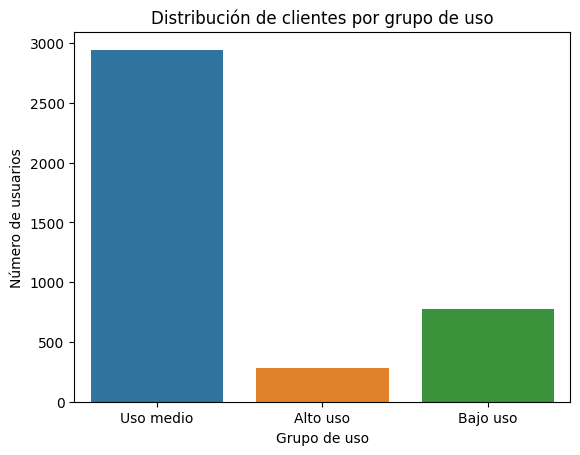

In [49]:

# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso')

plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Número de usuarios')

plt.show()

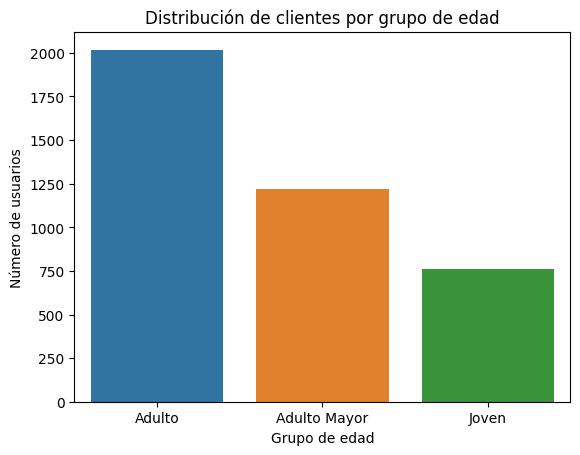

In [50]:
# Visualización de los segmentos por edad

sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Número de usuarios')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
-Se detectaron valores ausentes en varias columnas. En users, la columna city tenía 469 valores nulos (11,73%) y churn_date 3.534 valores nulos (88,35%). Los valores ausentes de churn_date son coherentes con usuarios que todavía no han abandonado el servicio.
En usage, había 50 fechas ausentes (0,125%), además de valores ausentes en duration (55,19%) y length (44,74%). Estos últimos se deben principalmente a que cada tipo de registro utiliza una variable diferente: las llamadas tienen duración y los mensajes tienen longitud.
También se encontraron valores anómalos, como -999 en la edad y ? en la ciudad. El valor -999 se sustituyó por la mediana de edad y los valores ? de ciudad se trataron como datos ausentes.
Además, se detectaron 40 fechas de registro posteriores a 2024, que se consideraron inválidas para el periodo analizado y se transformaron en valores nulos.

🔍 **Segmentos por Edad**
-Se clasificaron los clientes en tres grupos: Joven (menores de 30 años), Adulto (de 30 a 59 años) y Adulto Mayor (60 años o más).
La edad de los clientes se encuentra entre 18 y 79 años, con una edad media de aproximadamente 48 años. La distribución por edad es bastante amplia, por lo que ConnectaTel cuenta con una base de clientes de diferentes generaciones.

📊 **Segmentos por Nivel de Uso**
Se clasificaron los clientes según el número de llamadas y mensajes en Bajo uso, Uso medio y Alto uso.
Los usuarios de bajo uso realizan menos de 5 llamadas y menos de 5 mensajes, mientras que los usuarios de alto uso superan alguno de los umbrales establecidos. Esto permite diferenciar clientes según su intensidad de utilización del servicio.
En términos generales, el consumo de llamadas y mensajes se concentra en valores relativamente bajos y medios, aunque existe un grupo de usuarios con un consumo considerablemente superior.


Esto sugiere que ConnectaTel puede beneficiarse de una oferta más segmentada, adaptando los servicios a las necesidades y al nivel de consumo de cada tipo de cliente. El plan Básico representa aproximadamente el 64,9% de los usuarios, mientras que Premium representa el 35,1%, por lo que existe una base importante de clientes potenciales para estrategias de mejora de plan.

💡 Recomendaciones

Mantener una oferta diferenciada para clientes de bajo uso, evitando que paguen por recursos que no necesitan, y desarrollar opciones flexibles o económicas que ayuden a retenerlos.
Para los clientes de alto uso, especialmente aquellos con un consumo elevado de llamadas o mensajes, ofrecer planes Premium o planes con mayores límites puede aumentar los ingresos y reducir el riesgo de que el cliente busque alternativas en la competencia.
Analizar la posibilidad de crear planes intermedios, dirigidos a clientes de uso medio que puedan estar entre las necesidades del plan Básico y Premium.
Utilizar la edad y el nivel de uso conjuntamente para crear campañas más personalizadas, adaptando la comunicación y los beneficios a los diferentes perfiles.
Los outliers encontrados en total_mensajes, total_llamadas y total_minutos deben mantenerse, ya que representan clientes con un consumo elevado y no necesariamente errores. Estos usuarios pueden ser especialmente interesantes para diseñar ofertas de mayor capacidad o servicios Premium.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`